<a href="https://colab.research.google.com/github/Subhranshu-123/BIKE2/blob/main/Copy_of_excersise_4)dr_vinod_reddy).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Airline Passenger Demand Forecasting
Business Problem

Airlines need to forecast passenger demand to optimize:

Seat capacity

Ticket pricing

Revenue planning

Flight scheduling

Goal: Predict future passenger demand using historical airline data.

Import Libraries

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series Model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose

Load Airline Dataset

In [ ]:
df = pd.read_excel("/content/Airlines+Data.xlsx")

df.head()

,Month,Passengers
0,1995-01-01,112
1,1995-02-01,118
2,1995-03-01,132
3,1995-04-01,129
4,1995-05-01,121


In [ ]:
df["Month"] = pd.to_datetime(df["Month"])

df["Year"] = df["Month"].dt.year
df["Month_Name"] = df["Month"].dt.month

Calculate Monthly Average

In [ ]:
monthly_avg = df.groupby("Month_Name")["Passengers"].mean()

monthly_avg

,Passengers
Month_Name,
1,183.625
2,183.500
3,212.375
4,206.500
5,206.500
6,234.500
7,261.250
8,259.500
9,231.250


Calculate Overall Average

In [ ]:
overall_avg = df["Passengers"].mean()

overall_avg

np.float64(213.70833333333334)

seasonal Index Formula

Seasonal Index =

Seasonal Index=Monthly Average
Overall Average
Seasonal Index=
Overall Average/
Monthly Average
	​


In [ ]:
seasonal_index = monthly_avg / overall_avg

seasonal_index

,Passengers
Month_Name,
1,0.859232
2,0.858647
3,0.993761
4,0.966270
5,0.966270
6,1.097290
7,1.222461
8,1.214272
9,1.082082


Convert to Table

In [ ]:
seasonal_index_df = pd.DataFrame(seasonal_index)

seasonal_index_df.columns = ["Seasonal_Index"]

seasonal_index_df

,Seasonal_Index
Month_Name,
1,0.859232
2,0.858647
3,0.993761
4,0.966270
5,0.966270
6,1.097290
7,1.222461
8,1.214272
9,1.082082


Visualization

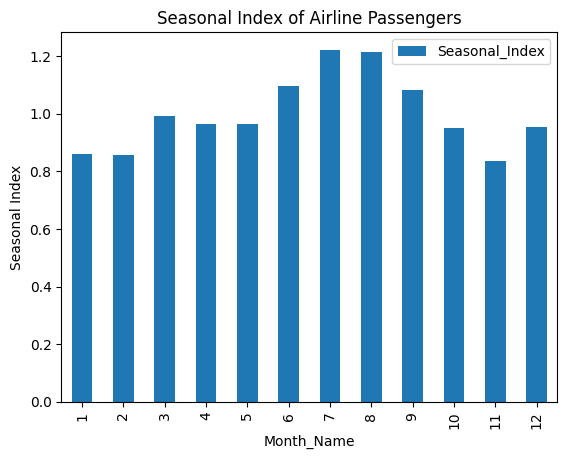

In [ ]:
seasonal_index_df.plot(kind="bar")

plt.title("Seasonal Index of Airline Passengers")

plt.ylabel("Seasonal Index")

plt.show()

Business Interpretation
Index Value	Meaning
>1	High demand season
<1	Low demand season
=1	Normal demand
June–August → High demand (summer travel)

January–February → Low demand

Data Preprocessing

Convert Month column into datetime.

In [ ]:
df["Month"] = pd.to_datetime(df["Month"])

df.set_index("Month", inplace=True)

df.head()

,Passengers,Year,Month_Name
Month,,,
1995-01-01,112,1995,1
1995-02-01,118,1995,2
1995-03-01,132,1995,3
1995-04-01,129,1995,4
1995-05-01,121,1995,5


ACF shows correlation between current value and past values.

Example:

Lag 1 → correlation with previous month

Lag 2 → correlation with two months ago

Is the data white noise (random)? If all bars (except lag 0) are within the confidence intervals (usually blue dashed lines), the data is likely random.
Is there a trend? A slow, linear decay in the bars often indicates a trend.
Is there seasonality? Significant spikes at specific, regular intervals (e.g., at lags 12, 24 for monthly data) suggest seasonal patterns.
What is the order of the Moving Average (MA) model? For a purely MA model, the ACF will "cut off" and become non-significant after a certain number of lags (
).

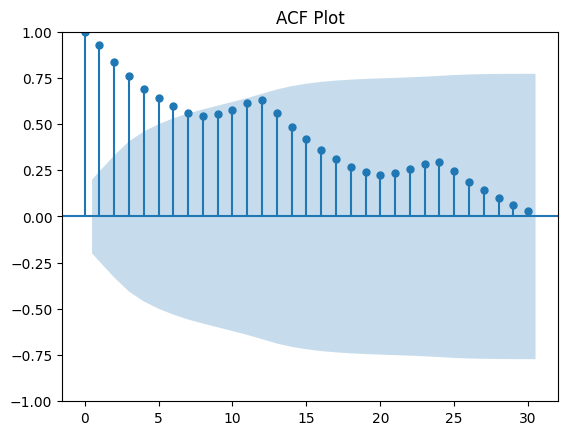

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["Passengers"], lags=30)

plt.title("ACF Plot")

plt.show()

PACF shows direct correlation after removing intermediate effects.

If PACF cuts off after lag p, then AR(p) model is suitable.

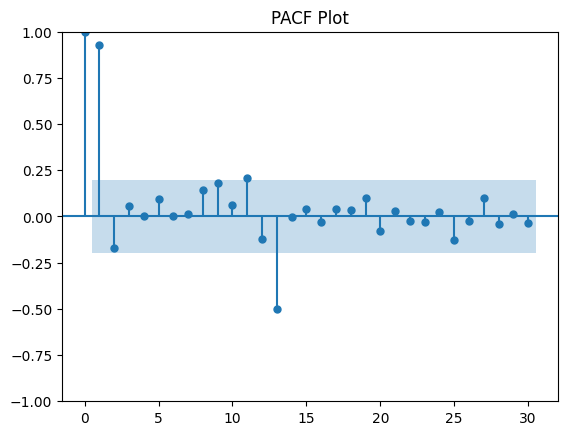

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df["Passengers"], lags=30)

plt.title("PACF Plot")

plt.show()

In [ ]:
df.columns

Index(['Passengers', 'Year', 'Month_Name'], dtype='object')

Exploratory Data Analysis (EDA)
Passenger Trend

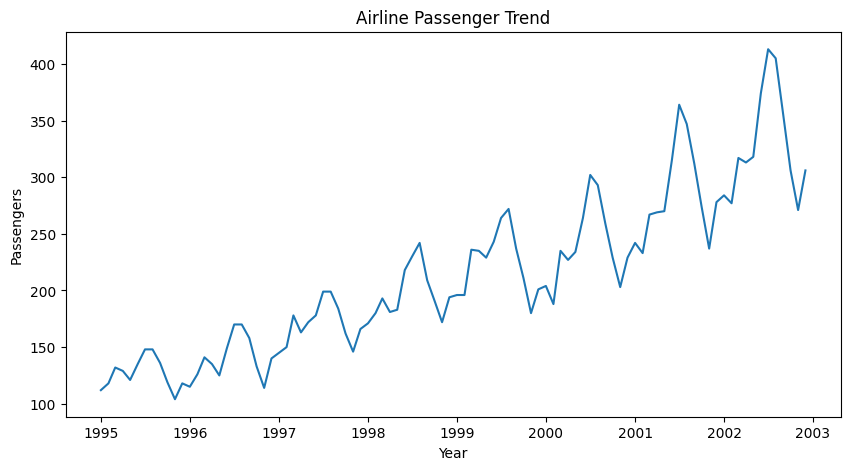

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(df["Passengers"])
plt.title("Airline Passenger Trend")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

Moving Average is a simple forecasting technique used to smooth fluctuations in time-series data and identify the trend in passenger demand.

Airlines use it to:

Predict future passenger demand

Plan seat capacity

Adjust flight schedules

3-Month Moving Average

Formula:

MA=Yt+Yt−1+Yt−2/3
MA=

Y
t
	​

+Y
t−1
	​

+Y
t−2/3
	​

	​


In [ ]:
df["MA_3"] = df["Passengers"].rolling(window=3).mean()

df.head()

,Passengers,Year,Month_Name,MA_3
Month,,,,
1995-01-01,112,1995,1,NaN
1995-02-01,118,1995,2,NaN
1995-03-01,132,1995,3,120.666667
1995-04-01,129,1995,4,126.333333
1995-05-01,121,1995,5,127.333333


6 Month Moving Average(identify longer trend)

In [ ]:
df["MA_6"] = df["Passengers"].rolling(window=6).mean()
df.head(10)

,Passengers,Year,Month_Name,MA_3,MA_6
Month,,,,,
1995-01-01,112,1995,1,NaN,NaN
1995-02-01,118,1995,2,NaN,NaN
1995-03-01,132,1995,3,120.666667,NaN
1995-04-01,129,1995,4,126.333333,NaN
1995-05-01,121,1995,5,127.333333,NaN
1995-06-01,135,1995,6,128.333333,124.500000
1995-07-01,148,1995,7,134.666667,130.500000
1995-08-01,148,1995,8,143.666667,135.500000
1995-09-01,136,1995,9,144.000000,136.166667


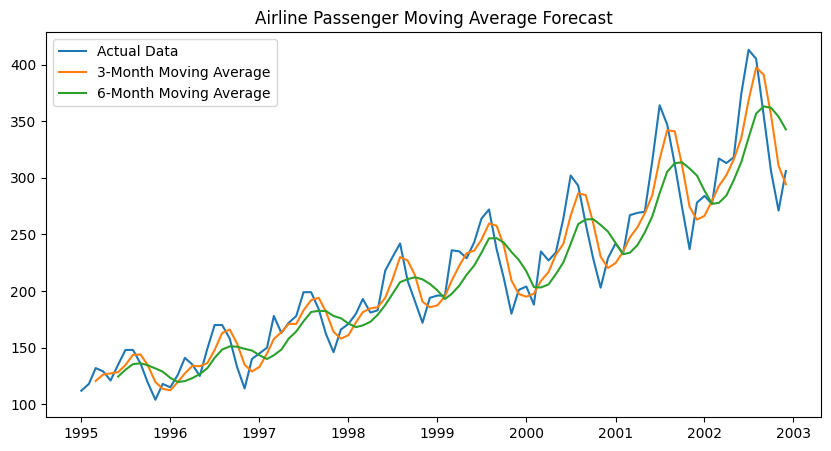

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["Passengers"], label="Actual Data")

plt.plot(df["MA_3"], label="3-Month Moving Average")

plt.plot(df["MA_6"], label="6-Month Moving Average")

plt.legend()

plt.title("Airline Passenger Moving Average Forecast")

plt.show()

Create Time Variable (t)

In [ ]:
df["t"] = np.arange(1, len(df)+1)

df.head()

,Passengers,Year,Month_Name,MA_3,MA_6,t
Month,,,,,,
1995-01-01,112,1995,1,NaN,NaN,1
1995-02-01,118,1995,2,NaN,NaN,2
1995-03-01,132,1995,3,120.666667,NaN,3
1995-04-01,129,1995,4,126.333333,NaN,4
1995-05-01,121,1995,5,127.333333,NaN,5


Build Trend Model

Trend equation:

Y=a+bt
Y=a+bt

Where

Y = Passenger demand

t = Time

a = intercept

b = trend slope

In [ ]:
from sklearn.linear_model import LinearRegression
X = df[["t"]]
y = df["Passengers"]

model = LinearRegression()

model.fit(X, y)

LinearRegression()

Predict Trend Values

In [ ]:
df["Trend"] = model.predict(X)

df.head()

,Passengers,Year,Month_Name,MA_3,MA_6,t,Trend
Month,,,,,,,
1995-01-01,112,1995,1,NaN,NaN,1,102.809493
1995-02-01,118,1995,2,NaN,NaN,2,105.144206
1995-03-01,132,1995,3,120.666667,NaN,3,107.478918
1995-04-01,129,1995,4,126.333333,NaN,4,109.813630
1995-05-01,121,1995,5,127.333333,NaN,5,112.148343


Plot Trend Projection

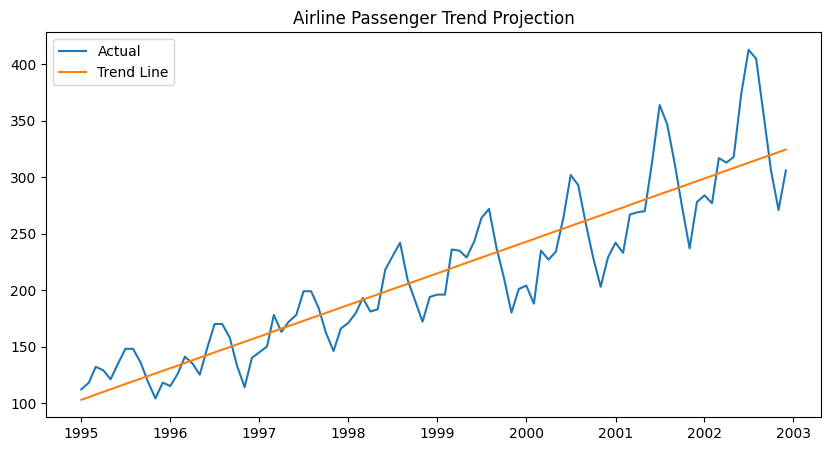

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["Passengers"], label="Actual")

plt.plot(df["Trend"], label="Trend Line")

plt.legend()

plt.title("Airline Passenger Trend Projection")

plt.show()

Forecast Future Demand

Predict next 12 months demand.
Business Interpretation

If trend slope (b) > 0
→ Passenger demand is increasing

If trend slope (b) < 0
→ Passenger demand is decreasing

In [ ]:
future_t = np.arange(len(df)+1, len(df)+13)

future_pred = model.predict(future_t.reshape(-1,1))

print(future_pred)

[326.94188596 329.27659839 331.61131082 333.94602324 336.28073567
 338.61544809 340.95016052 343.28487294 345.61958537 347.95429779
 350.28901022 352.62372264]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Business Insight:

Passenger demand increases over time

Seasonal travel pattern exists

Time Series Decomposition

Identify Trend + Seasonality + Residuals

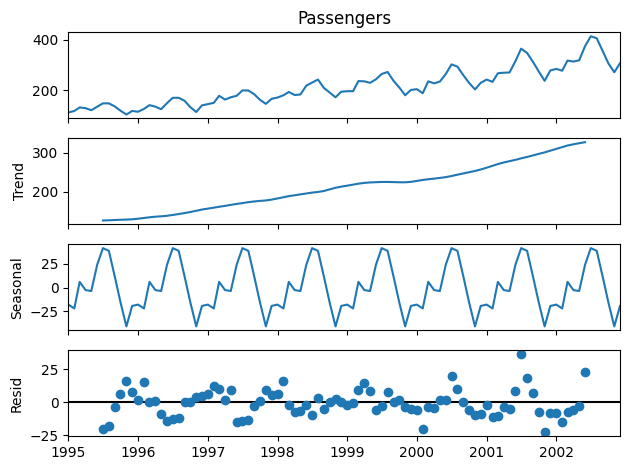

In [ ]:
decompose = seasonal_decompose(df["Passengers"], model="additive")

decompose.plot()
plt.show()

Business Insight:

Trend → passenger growth

Seasonality → peak travel months

Residual → random variation

Check Stationarity

Stationarity is required for time series models.

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Passengers"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 1.3402479596467138
p-value: 0.9968250481137263


Interpretation:

p < 0.05 → stationary

p > 0.05 → non-stationary

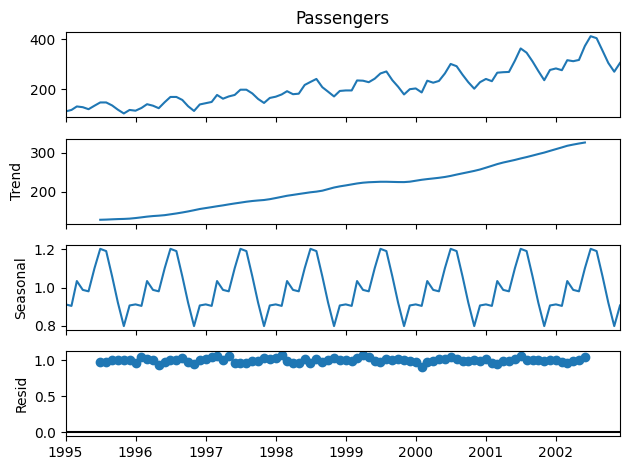

In [ ]:
decompose = seasonal_decompose(df["Passengers"], model="multiplicative")

decompose.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Passengers"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: 1.3402479596467138
p-value: 0.9968250481137263


Multiplicative Seasonal Model vs Additive Model
Multiplicative Seasonal Model

The Multiplicative Seasonal Model assumes that seasonal variation changes proportionally with the level of the time series.

Model form:

Yt=Tt×St×Ct×It

	​


Where

T = Trend

S = Seasonal

C = Cyclical

I = Irregular

Meaning:
Seasonal effect is a percentage of the trend, not a fixed number.

Additive Seasonal Model

The Additive Model assumes seasonal variation is constant over time.

Model form:

Yt=Tt+St+Ct+It

	​


Meaning:
Seasonal effect is a fixed amount added or subtracted each period.

The multiplicative seasonal model is preferred when seasonal variations increase proportionally with the level of the time series, which is common in airline passenger data where higher demand leads to larger seasonal fluctuations.

In [ ]:
df["log_passengers"] = np.log(df["Passengers"])

df.head()

,Passengers,Year,Month_Name,MA_3,MA_6,t,Trend,log_passengers
Month,,,,,,,,
1995-01-01,112,1995,1,NaN,NaN,1,102.809493,4.718499
1995-02-01,118,1995,2,NaN,NaN,2,105.144206,4.770685
1995-03-01,132,1995,3,120.666667,NaN,3,107.478918,4.882802
1995-04-01,129,1995,4,126.333333,NaN,4,109.813630,4.859812
1995-05-01,121,1995,5,127.333333,NaN,5,112.148343,4.795791


Plot Log Transformed Data

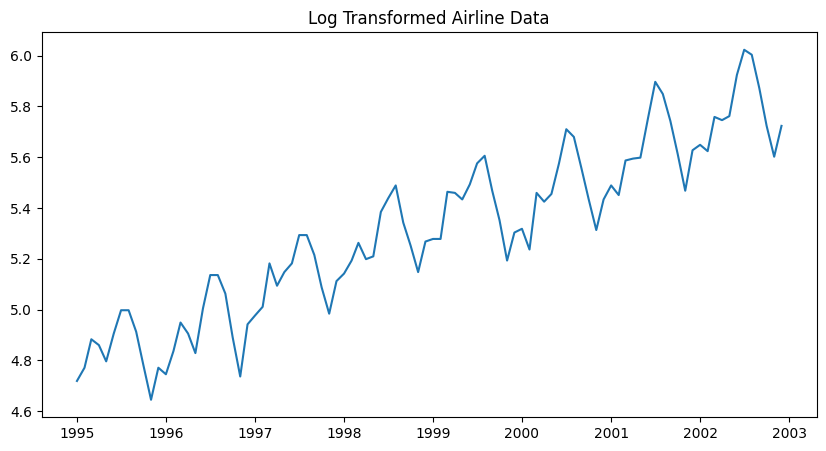

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["log_passengers"])

plt.title("Log Transformed Airline Data")

plt.show()

Decompose Log Data

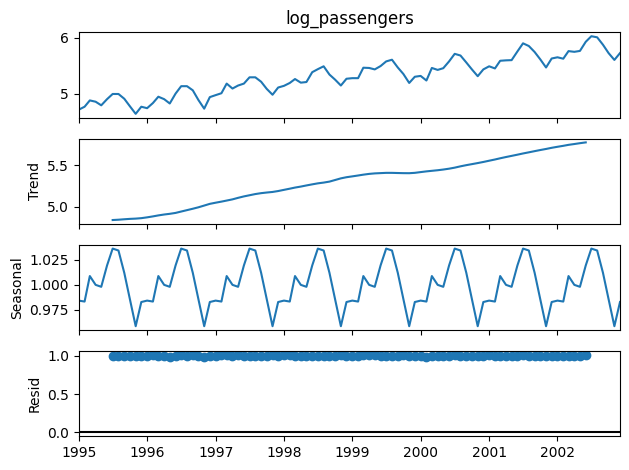

In [ ]:
decompose = seasonal_decompose(df["log_passengers"], model="multiplicative", period=12)

decompose.plot()

plt.show()

Differencing (if needed)

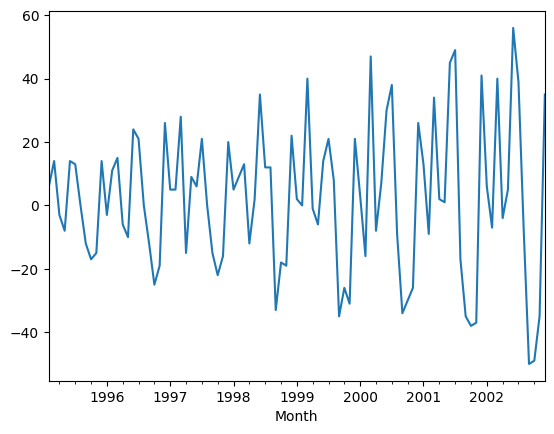

In [ ]:
df["Passengers_diff"] = df["Passengers"].diff()

df["Passengers_diff"].dropna().plot()
plt.show()

Convert Month Data to Daily Data

In [ ]:
daily_data = df.resample("D").interpolate(method="linear")

daily_data.head()

,Passengers,Year,Month_Name,MA_3,MA_6,t,Trend,log_passengers,Passengers_diff
Month,,,,,,,,,
1995-01-01,112.000000,1995.0,1.000000,NaN,NaN,1.000000,102.809493,4.718499,NaN
1995-01-02,112.193548,1995.0,1.032258,NaN,NaN,1.032258,102.884806,4.720182,NaN
1995-01-03,112.387097,1995.0,1.064516,NaN,NaN,1.064516,102.960120,4.721866,NaN
1995-01-04,112.580645,1995.0,1.096774,NaN,NaN,1.096774,103.035433,4.723549,NaN
1995-01-05,112.774194,1995.0,1.129032,NaN,NaN,1.129032,103.110746,4.725233,NaN


In [ ]:
hourly_data = daily_data.resample("H").interpolate(method="linear")

hourly_data.head()

/tmp/ipykernel_18812/2171553355.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = daily_data.resample("H").interpolate(method="linear")


,Passengers,Year,Month_Name,MA_3,MA_6,t,Trend,log_passengers,Passengers_diff
Month,,,,,,,,,
1995-01-01 00:00:00,112.000000,1995.0,1.000000,NaN,NaN,1.000000,102.809493,4.718499,NaN
1995-01-01 01:00:00,112.008065,1995.0,1.001344,NaN,NaN,1.001344,102.812631,4.718569,NaN
1995-01-01 02:00:00,112.016129,1995.0,1.002688,NaN,NaN,1.002688,102.815769,4.718639,NaN
1995-01-01 03:00:00,112.024194,1995.0,1.004032,NaN,NaN,1.004032,102.818907,4.718709,NaN
1995-01-01 04:00:00,112.032258,1995.0,1.005376,NaN,NaN,1.005376,102.822045,4.718779,NaN


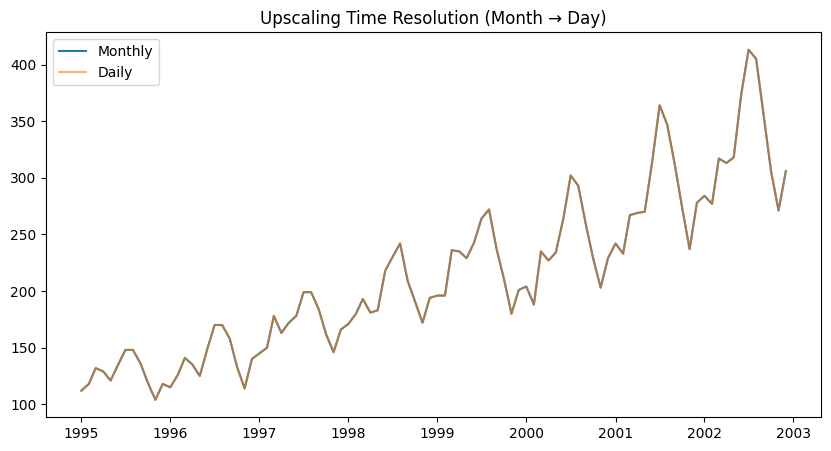

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(df["Passengers"], label="Monthly")

plt.plot(daily_data["Passengers"], label="Daily", alpha=0.6)

plt.legend()

plt.title("Upscaling Time Resolution (Month → Day)")

plt.show()

In [ ]:
df = pd.read_excel("Airlines+Data.xlsx")

df["Month"] = pd.to_datetime(df["Month"])

df.set_index("Month", inplace=True)

df.head()

,Passengers
Month,
1995-01-01,112
1995-02-01,118
1995-03-01,132
1995-04-01,129
1995-05-01,121


Convert Monthly Data to Yearly Data

In [ ]:
yearly_data = df.resample("Y").sum()

yearly_data.head()

/tmp/ipykernel_18812/138835285.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_data = df.resample("Y").sum()


,Passengers
Month,
1995-12-31,1520
1996-12-31,1676
1997-12-31,2042
1998-12-31,2364
1999-12-31,2700


Monthly vs Yearly

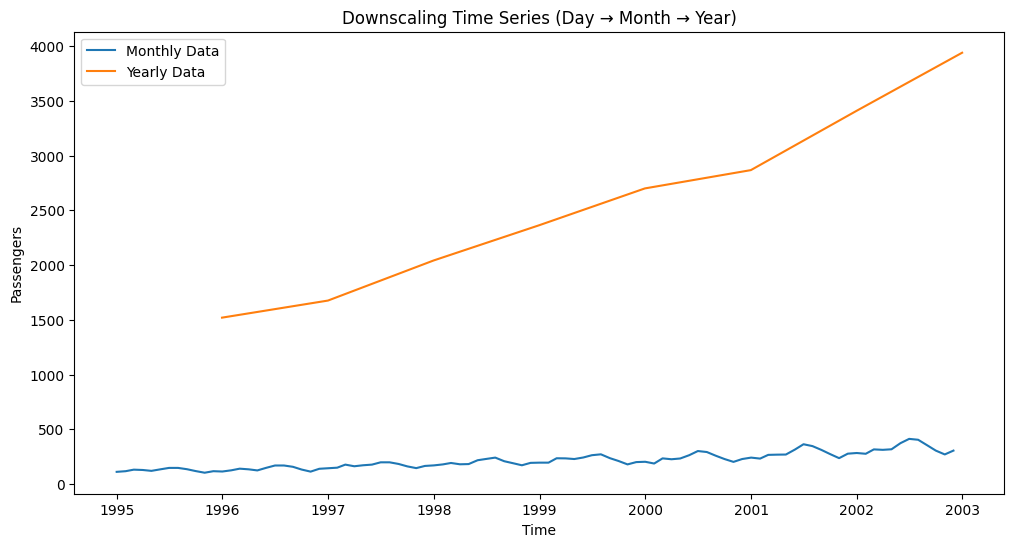

In [ ]:
plt.figure(figsize=(12,6))



plt.plot(df["Passengers"], label="Monthly Data")

plt.plot(yearly_data["Passengers"], label="Yearly Data")

plt.legend()

plt.title("Downscaling Time Series (Day → Month → Year)")

plt.xlabel("Time")

plt.ylabel("Passengers")

plt.show()

Purpose:

Remove trend

Stabilize time series

Downscaling (Removing Seasonality)

Downscaling means removing the seasonal effect from the data to get the true trend level.

Formula:

Deseasonalized Value=Actual Value/Seasonal Index



Business Reason:

Airlines remove seasonality to understand the real growth trend in passenger demand, independent of seasonal peaks like summer travel or holidays.

In [ ]:
monthly_avg = df.groupby("Month_Name")["Passengers"].mean()

overall_avg = df["Passengers"].mean()

seasonal_index = monthly_avg / overall_avg

seasonal_index

,Passengers
Month_Name,
1,0.859232
2,0.858647
3,0.993761
4,0.966270
5,0.966270
6,1.097290
7,1.222461
8,1.214272
9,1.082082


Map Seasonal Index to Dataset

In [ ]:
df["Seasonal_Index"] = df["Month_Name"].map(seasonal_index)

df.head()

,Passengers,Year,Month_Name,MA_3,MA_6,t,Trend,log_passengers,Passengers_diff,Seasonal_Index
Month,,,,,,,,,,
1995-01-01,112,1995,1,NaN,NaN,1,102.809493,4.718499,NaN,0.859232
1995-02-01,118,1995,2,NaN,NaN,2,105.144206,4.770685,6.0,0.858647
1995-03-01,132,1995,3,120.666667,NaN,3,107.478918,4.882802,14.0,0.993761
1995-04-01,129,1995,4,126.333333,NaN,4,109.813630,4.859812,-3.0,0.966270
1995-05-01,121,1995,5,127.333333,NaN,5,112.148343,4.795791,-8.0,0.966270


Downscaling (Deseasonalizing Data)
Interpretation:

This removes seasonal peaks and shows the true demand trend.

In [ ]:
df["Deseasonalized"] = df["Passengers"] / df["Seasonal_Index"]

df.head()

,Passengers,Year,Month_Name,MA_3,MA_6,t,Trend,log_passengers,Passengers_diff,Seasonal_Index,Deseasonalized
Month,,,,,,,,,,,
1995-01-01,112,1995,1,NaN,NaN,1,102.809493,4.718499,NaN,0.859232,130.348990
1995-02-01,118,1995,2,NaN,NaN,2,105.144206,4.770685,6.0,0.858647,137.425522
1995-03-01,132,1995,3,120.666667,NaN,3,107.478918,4.882802,14.0,0.993761,132.828723
1995-04-01,129,1995,4,126.333333,NaN,4,109.813630,4.859812,-3.0,0.966270,133.503027
1995-05-01,121,1995,5,127.333333,NaN,5,112.148343,4.795791,-8.0,0.966270,125.223769


Upscaling (Adding Seasonality Back)

After forecasting the trend values, we add seasonal effects back.

Formula:

Forecast=Trend Forecast×Seasonal Index
Forecast=Trend Forecast×Seasonal Index

Business Reason:

Airlines reintroduce seasonal effects to produce realistic passenger demand forecasts for specific months.

Example:

December → Holiday demand increases

February → Lower travel demand

In [ ]:
#suppose 204 passenger
trend_forecast = 204

seasonal_index_dec = 0.954572

forecast_december = trend_forecast * seasonal_index_dec

print(forecast_december)
#actual expected passenger 195

194.732688


In [ ]:
df["Reseasonalized"] = df["Deseasonalized"] * df["Seasonal_Index"]

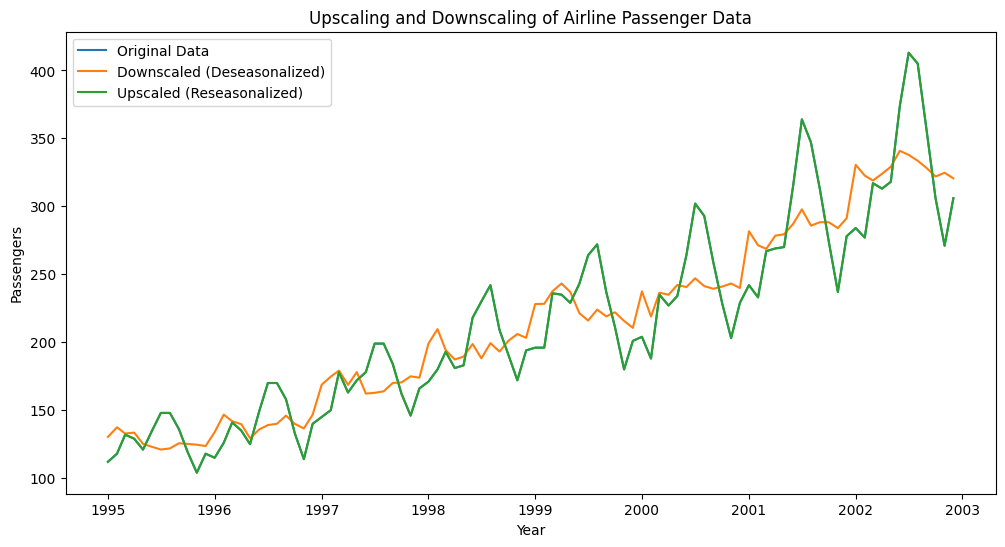

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df["Passengers"], label="Original Data")

plt.plot(df["Deseasonalized"], label="Downscaled (Deseasonalized)")

plt.plot(df["Reseasonalized"], label="Upscaled (Reseasonalized)")

plt.legend()

plt.title("Upscaling and Downscaling of Airline Passenger Data")

plt.xlabel("Year")

plt.ylabel("Passengers")

plt.show()

Build Forecast Model (ARIMA)

In [ ]:


model = ARIMA(df["Passengers"], order=(2,1,2))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                   96
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -423.359
Date:                Thu, 12 Mar 2026   AIC                            856.719
Time:                        05:58:03   BIC                            869.488
Sample:                    01-01-1995   HQIC                           861.879
                         - 12-01-2002                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1586      0.224      5.183      0.000       0.721       1.597
ar.L2         -0.5555      0.228     -2.438      0.015      -1.002      -0.109
ma.L1         -0.9803      0.232     -4.218      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Forecast Future Passenger Demand

In [ ]:
forecast = model_fit.forecast(steps=12)

print(forecast)

2003-01-01    331.411246
2003-02-01    346.575586
2003-03-01    350.029556
2003-04-01    345.607688
2003-05-01    338.565725
2003-06-01    332.863045
2003-07-01    330.167547
2003-08-01    330.212286
2003-09-01    331.761460
2003-10-01    333.531524
2003-11-01    334.721807
2003-12-01    335.117639
Freq: MS, Name: predicted_mean, dtype: float64


Visualize Forecast

/tmp/ipykernel_18812/1392805634.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(df.index[-1], periods=12, freq="M")


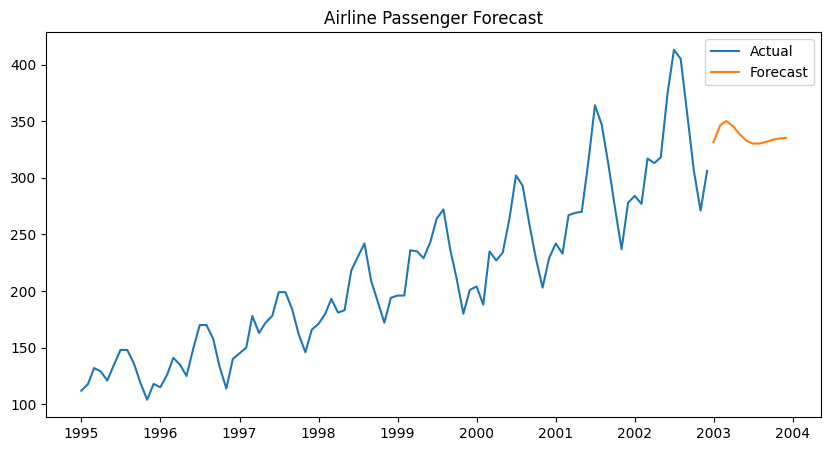

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(df["Passengers"], label="Actual")

future_index = pd.date_range(df.index[-1], periods=12, freq="M")

plt.plot(future_index, forecast, label="Forecast")

plt.legend()

plt.title("Airline Passenger Forecast")

plt.show()

Business Revenue Estimation

Airlines can estimate future revenue.

In [ ]:
seat_capacity = 180
ticket_price = 6500

predicted_demand = forecast.mean()

revenue = min(predicted_demand, seat_capacity) * ticket_price

print("Expected Revenue:", revenue)

Expected Revenue: 1170000
